# 12 - Transformer (Part 2: Self-Attention)

---

This notebook explains the core idea behind the Transformer:

**Self-Attention**

If you understand this notebook,

you understand the most important operation in modern Large Language Models.

## 📜 History

Researchers had removed RNNs.

Great.

Now every word could be processed simultaneously.

But a new question appeared.

Suppose we have

"The animal didn't cross the street because it was tired."

When processing

it

which previous word should the model look at?

animal?

street?

cross?

The model must decide automatically.

This idea became

Self-Attention.

## 💡 Think Like a Google Researcher

Imagine you're designing the next generation of Google Translate.

Question:

Should every word receive equal importance?

No.

Different words become important in different contexts.

The model must learn

where to look.

This became Self-Attention.

## 💡 Core Idea

Every word asks:

Which other words are important for understanding me?

Instead of reading sequentially,

every token can communicate directly with every other token.

This communication is called

Self-Attention.

In [1]:
sentence = [
    "The",
    "animal",
    "didn't",
    "cross",
    "the",
    "street",
    "because",
    "it",
    "was",
    "tired"
]

print(sentence)

['The', 'animal', "didn't", 'cross', 'the', 'street', 'because', 'it', 'was', 'tired']


## 🧠 Think

When understanding the word

it

which word should receive the highest attention?

Possible answers:

- animal ✅

- street ❌

- because ❌

- cross ❌

Humans know the answer immediately.

Can the model learn this automatically?

Yes.

In [2]:
import pandas as pd

words = sentence

scores = [
    0.02,
    0.55,
    0.01,
    0.03,
    0.02,
    0.04,
    0.05,
    0.20,
    0.04,
    0.04
]

pd.DataFrame({
    "Word":words,
    "Attention":scores
})

,Word,Attention
0,The,0.02
1,animal,0.55
2,didn't,0.01
3,cross,0.03
4,the,0.02
5,street,0.04
6,because,0.05
7,it,0.20
8,was,0.04
9,tired,0.04


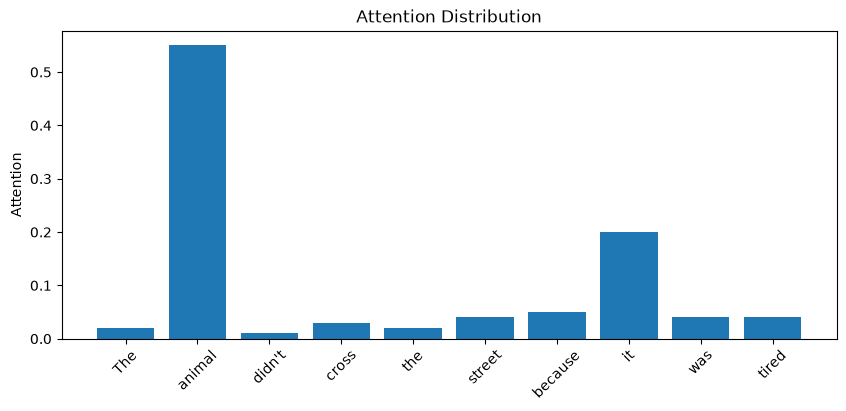

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.bar(words,scores)

plt.xticks(rotation=45)

plt.ylabel("Attention")

plt.title("Attention Distribution")

plt.show()


# Higher bar --->more important

## 🧠 Internal Process

Every token creates

Query

↓

Key

↓

Value

These three vectors are learned during training.

The model compares

Query

with

every Key.

The matching Values become important.

## 🍽 Restaurant Analogy

Imagine

You = Query

Menu = Keys

Food = Values

You search the menu.

Find the best match.

Receive the food.

Exactly the same idea.

Attention retrieves the most relevant information.

## 🔍 Query

Query means

"What am I looking for?"

Example

Current word

↓

it

The Query asks

Which previous word explains me?

## 🔑 Key

Every word provides a Key.

Think of Keys as labels.

The Query compares itself with every Key.

Higher similarity

↓

Higher attention.

## 📦 Value

Value contains the actual information.

After selecting important Keys,

the model combines their Values.

This produces the final representation.

In [7]:
queries = ["it"]

keys = [
    "animal",
    "street",
    "cross"
]

print("Query")

print(queries)

print()

print("Keys")

print(keys)

Query
['it']

Keys
['animal', 'street', 'cross']


## ➗ Dot Product

How do we compare Query and Key?

The Transformer computes

Query

•

Key

Higher value

↓

More similar

↓

Higher attention

In [9]:
import numpy as np

query = np.array([1,2])

key1 = np.array([1,2])

key2 = np.array([8,-1])

print(np.dot(query,key1))

print(np.dot(query,key2))

5
6


Larger score

↓

More relevant

## 🧠 Why Softmax?

Dot products can be

10

5

2

-3

These are difficult to interpret.

Softmax converts them into probabilities.

All probabilities add up to 1

In [10]:
scores = np.array([5,2,1])

softmax = np.exp(scores)/np.sum(np.exp(scores))

print(softmax)

[0.93623955 0.04661262 0.01714783]


## 📊 Pipeline

Query

↓

Compare with Keys

↓

Dot Products

↓

Softmax

↓

Attention Scores

↓

Weighted Values

↓

Final Output

In [11]:
import torch
import torch.nn.functional as F

torch.manual_seed(42)

X = torch.rand(3,4)

Q = X

K = X

V = X

scores = Q @ K.T

attention = F.softmax(scores,dim=-1)

output = attention @ V

print(output)

tensor([[0.7910, 0.6577, 0.4899, 0.8349],
        [0.7635, 0.6273, 0.4912, 0.8196],
        [0.8230, 0.4976, 0.6163, 0.7608]])


## 📊 Attention vs Self-Attention

Attention

Decoder looks at Encoder.

Self-Attention

Words inside the same sentence look at each other.

Transformer Encoder

↓

Self-Attention

Transformer Decoder

↓

Self-Attention

### +

Cross-Attention

## 🧠 Why One Attention Isn't Enough?

One head may focus on

Grammar.

Another

Meaning.

Another

Pronouns.

Another

Long-distance relationships.

Instead of one Attention,

the Transformer uses

Multiple Heads.

Head 1

Grammar

↓

Head 2

Subject

↓

Head 3

Verb

↓

Head 4

Meaning

↓

Concatenate

↓

Final Output

## ✅ Advantages

- Parallel computation
- Better long-range understanding
- Dynamic context
- Faster training
- Better language understanding

## ✅ Summary

Today I learned

- Self-Attention

- Query

- Key

- Value

- Dot Product

- Softmax

- Scaled Dot Product

- Multi-Head Attention

These are the core building blocks of the Transformer.

## 🧠 Think Like a Researcher

We have learned Self-Attention.

Great.

But a Transformer contains much more.

Question:

How do we build an entire Transformer block?

What comes after Self-Attention?

Residual Connections?

Layer Normalization?

Feed Forward Networks?

Encoder?

Decoder?

Let's build them next.